# Book 2 — RF and XGBoost Baselines for Three-Class Urban Morphology

This notebook is the main tabular machine-learning workflow. It runs in Google Colab after Book 0 and Book 1 have produced OSM layers and Earth Engine grid features.

**Input**: Book 1 grid-feature CSVs, Book 0 candidate GeoJSONs, and Book 0 road GeoJSONs.  
**Output**: weak-labelled grid tables, RF/XGBoost metrics, feature ablation, SHAP explanations, prediction maps, and the processed input table for Book 3.  
**Runtime**: typically 20-45 minutes on Colab, with SHAP and GeoJSON export being the slowest steps.  
**Role in the pipeline**: establishes leakage-free tabular baselines and prepares the exact feature matrix used by the GraphSAGE extension.


### Step 0: Mount Google Drive

**Purpose**: Make the project files in Google Drive available to Colab before package installation and data loading.  
**Input**: Google Drive authentication.  
**Output**: mounted Drive path for all Book 2 inputs and outputs.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 1: Install packages and define class constants

**Purpose**: Install the geospatial, machine-learning, explainability, and emissions-tracking libraries used in the tabular workflow.  
**Input**: Colab runtime.  
**Output**: imported libraries, fixed random seed, and the three-class label scheme used throughout the notebook.


In [3]:
# ----------------------------------------------------------------------------
# 1. Install and import packages
# ----------------------------------------------------------------------------
# In Colab, run this cell once. Restart runtime only if Colab asks you to.

!pip -q install geopandas shapely pyproj rtree xgboost shap codecarbon folium mapclassify
!pip -q install imbalanced-learn

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import shap

try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
except Exception:
    CODECARBON_AVAILABLE = False

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Three-class label scheme used throughout this notebook
CLASS_GREEN = 0           # urban green: parks, vegetation, water in urban context
CLASS_NORMAL = 1          # normal built-up: CBD, formal residential, industrial
CLASS_VILLAGE = 2         # urban village: dense informal settlement
CLASS_AMBIGUOUS = -1      # excluded from training (does not meet any rule)

CLASS_NAMES = {
    CLASS_GREEN: "urban_green",
    CLASS_NORMAL: "normal_built_up",
    CLASS_VILLAGE: "urban_village",
}
CLASS_ORDER = [CLASS_GREEN, CLASS_NORMAL, CLASS_VILLAGE]
CLASS_LABELS_ORDERED = [CLASS_NAMES[c] for c in CLASS_ORDER]
CLASS_COLORS = {
    CLASS_GREEN: "#4daf4a",
    CLASS_NORMAL: "#377eb8",
    CLASS_VILLAGE: "#e41a1c",
}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.5/380.5 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 113.6 MB/s eta 0:00:00


### Step 2: Define project paths and city CRS metadata

**Purpose**: Point the notebook to Book 1 exports, Book 0 OSM layers, processed outputs, and city-specific projected CRSs.  
**Input**: Google Drive project structure.  
**Output**: path variables and CRS helpers for distance, overlap, and road-density calculations.


In [4]:
# ----------------------------------------------------------------------------
# 2. Mount Google Drive and define project paths
# ----------------------------------------------------------------------------
# Expected Google Drive structure:
#
# /content/drive/MyDrive/0069/week10/
#   book1_gee_exports/
#     book1_grid_features_guangzhou_2024.csv
#     book1_grid_features_beijing_2024.csv
#     book1_grid_features_xian_2024.csv
#   osm_candidates/
#     guangzhou_candidates.geojson
#     beijing_candidates.geojson
#     xian_candidates.geojson
#   osm_roads/
#     guangzhou_roads.geojson
#     xian_roads.geojson
#   processed/
#   outputs/
#
# The OSM candidate GeoJSON files can be exported from QGIS / Overpass Turbo.
# Candidate features should include:
# - place=village
# - place=hamlet
# - landuse=residential + residential=rural

from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/0069/week10")
GEE_EXPORT_DIR = PROJECT_DIR / "book1_gee_exports"
OSM_CANDIDATE_DIR = PROJECT_DIR / "osm_candidates"
OSM_ROAD_DIR = PROJECT_DIR / "osm_roads"
PROCESSED_DIR = PROJECT_DIR / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"

for p in [PROCESSED_DIR, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CITY_UTM_CRS = {
    "guangzhou": "EPSG:32649",
    "shenzhen": "EPSG:32649",
    "tianjin": "EPSG:32650",
    "beijing": "EPSG:32650",
    "dongguan": "EPSG:32649",
    "shanghai": "EPSG:32651",
    "chongqing": "EPSG:32648",
    "xian": "EPSG:32649",
    "wuhan": "EPSG:32650",
    "chengdu": "EPSG:32648",
}

def city_metric_crs(city: str) -> str:
    return CITY_UTM_CRS.get(str(city), "EPSG:3857")

print("Project dir:", PROJECT_DIR)
print("GEE export dir exists:", GEE_EXPORT_DIR.exists())
print("OSM candidate dir exists:", OSM_CANDIDATE_DIR.exists())
print("OSM road dir exists:", OSM_ROAD_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/0069/week10
GEE export dir exists: True
OSM candidate dir exists: True
OSM road dir exists: True


### Step 3: Load GEE-exported grid features

**Purpose**: Read the per-city CSVs exported by Book 1 and reconstruct grid geometries from the `.geo` column.  
**Input**: `book1_grid_features_{city}_{year}.csv` files.  
**Output**: a single GeoDataFrame where each row is one 250 m grid cell with EO/context features.


In [5]:
# ----------------------------------------------------------------------------
# 3. Load GEE-exported grid features
# ----------------------------------------------------------------------------
# GEE CSV exports usually include a `.geo` column. We convert it back into
# geometry so later we can compute distance/overlap with OSM candidates.

def load_gee_csv(csv_path: Path) -> gpd.GeoDataFrame:
    df = pd.read_csv(csv_path)

    if ".geo" not in df.columns:
        raise ValueError(f"{csv_path.name} has no .geo column. Re-export from GEE with geometries.")

    geometries = df[".geo"].apply(lambda x: shape(json.loads(x)))
    gdf = gpd.GeoDataFrame(df.drop(columns=[".geo"]), geometry=geometries, crs="EPSG:4326")

    if "city" not in gdf.columns:
        # Infer city from filename: book1_grid_features_guangzhou_2024.csv
        parts = csv_path.stem.split("_")
        city = parts[3] if len(parts) >= 5 else csv_path.stem
        gdf["city"] = city

    return gdf

csv_files = sorted(GEE_EXPORT_DIR.glob("book1_grid_features_*_*.csv"))
print("Found CSV files:", [p.name for p in csv_files])

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No GEE export CSV found. Run Book 1 in GEE first and export files to "
        f"{GEE_EXPORT_DIR}."
    )

grid_gdfs = [load_gee_csv(p) for p in csv_files]
grids = pd.concat(grid_gdfs, ignore_index=True)
grids = gpd.GeoDataFrame(grids, geometry="geometry", crs="EPSG:4326")

print(grids.shape)
print(grids[["city", "grid_id"]].head())
print(grids["city"].value_counts())

Found CSV files: ['book1_grid_features_beijing_2025.csv', 'book1_grid_features_chengdu_2025.csv', 'book1_grid_features_chongqing_2025.csv', 'book1_grid_features_dongguan_2025.csv', 'book1_grid_features_guangzhou_2025.csv', 'book1_grid_features_shanghai_2025.csv', 'book1_grid_features_shenzhen_2025.csv', 'book1_grid_features_tianjin_2025.csv', 'book1_grid_features_wuhan_2025.csv', 'book1_grid_features_xian_2025.csv']
(333674, 82)
      city      grid_id
0  beijing  16770017645
1  beijing  16770017646
2  beijing  16780017641
3  beijing  16780017644
4  beijing  16780017645
city
shanghai     74353
beijing      51938
tianjin      43370
guangzhou    39358
chengdu      32322
dongguan     29186
shenzhen     20216
xian         17329
chongqing    14742
wuhan        10860
Name: count, dtype: int64


### Step 4: Attach OSM candidate distance and overlap

**Purpose**: This step originally measured each grid cell's distance to the nearest OSM village/hamlet/locality candidate and its polygon overlap with OSM candidate areas. These two variables are used only to construct weak labels; they are explicitly removed from the model feature matrix later to avoid data leakage.  
**Input**: grid geometries and `{city}_candidates.geojson` files generated in Book 0.  
**Output when run by the author**: `dist_to_osm_candidate_m` and `osm_candidate_overlap` attached to the processed grid table.

**Reproducibility note**: this operation is intentionally not re-run in the public notebook because it is a slow spatial join over all city grids and OSM candidate geometries. The attached version was generated once during project development and saved in the author's Google Drive working directory. If the cached processed table is required for independent checking, please contact the author.


#### Cached Step 4 output

This code cell has been replaced by a markdown note in the submitted version. The original operation computed:

- `dist_to_osm_candidate_m`: distance from each grid centroid to the nearest OSM candidate feature;
- `osm_candidate_overlap`: fraction of grid area overlapping an OSM candidate polygon.

These columns are weak-supervision variables, not predictor variables. They are needed to reproduce the exact weak labels, but they should not be included in `X`. Re-running the spatial join is unnecessary for the final submitted results because the processed table has already been generated and cached by the author.


# ----------------------------------------------------------------------------
# 4. Attach OSM candidate distance and overlap
# ----------------------------------------------------------------------------
# This creates the weak-supervision signal.
#
# If Book 1 already attached `dist_to_osm_candidate_m` and
# `osm_candidate_overlap`, this cell keeps those columns.
#
# If not, it reads one GeoJSON per city:
#   osm_candidates/guangzhou_candidates.geojson
#   osm_candidates/xian_candidates.geojson
#
# These candidates are incomplete but high-precision reference positives. They
# are used to construct labels, not to give the model a shortcut feature.

def add_osm_candidate_features(city_gdf: gpd.GeoDataFrame, candidate_path: Path) -> gpd.GeoDataFrame:
    city = str(city_gdf["city"].iloc[0])
    out = city_gdf.copy()

    if {"dist_to_osm_candidate_m", "osm_candidate_overlap"}.issubset(out.columns):
        print(f"{city}: OSM distance/overlap already exist from GEE.")
        return out

    if not candidate_path.exists():
        print(f"{city}: no candidate file found at {candidate_path}. OSM features set to NaN.")
        out["dist_to_osm_candidate_m"] = np.nan
        out["osm_candidate_overlap"] = np.nan
        return out

    metric_crs = city_metric_crs(city)
    cand = gpd.read_file(candidate_path).to_crs(metric_crs)
    city_m = out.to_crs(metric_crs)
    cand = cand[cand.geometry.notna() & ~cand.geometry.is_empty]

    if len(cand) == 0:
        print(f"{city}: candidate file is empty.")
        out["dist_to_osm_candidate_m"] = np.nan
        out["osm_candidate_overlap"] = np.nan
        return out

    candidate_union = cand.geometry.union_all()
    city_m["dist_to_osm_candidate_m"] = city_m.geometry.centroid.distance(candidate_union)
    city_m["osm_candidate_overlap"] = (
        city_m.geometry.intersection(candidate_union).area / city_m.geometry.area
    )

    return city_m.to_crs("EPSG:4326")

pieces = []
for city, city_gdf in grids.groupby("city"):
    candidate_path = OSM_CANDIDATE_DIR / f"{city}_candidates.geojson"
    pieces.append(add_osm_candidate_features(city_gdf, candidate_path))

grids = pd.concat(pieces, ignore_index=True)
grids = gpd.GeoDataFrame(grids, geometry="geometry", crs="EPSG:4326")

print(grids[["city", "dist_to_osm_candidate_m", "osm_candidate_overlap"]].head())

### Step 5: Attach OSM road morphology features

**Purpose**: This step originally computed road density inside each grid cell as an interpretable morphology feature. Unlike OSM village distance/overlap, road density is not part of the weak-label rule and is therefore retained as a valid predictor.  
**Input**: grid geometries and `{city}_roads.geojson` files generated in Book 0.  
**Output when run by the author**: `road_density_m_per_km2`, used as one of the model features.

**Reproducibility note**: this operation is intentionally not re-run in the public notebook because it is a slow line-polygon intersection over all road geometries and grid cells. The attached road-density column was generated once during project development and saved in the author's Google Drive working directory. If the cached processed table is required for independent checking, please contact the author.


#### Cached Step 5 output

This code cell has been replaced by a markdown note in the submitted version. The original operation computed `road_density_m_per_km2` by intersecting each 250 m grid cell with the OSM road network and dividing total road length by grid-cell area.

This variable is retained in the model feature matrix because it describes urban morphology rather than the OSM village/hamlet candidate signal used for weak labelling. Re-running the road-density calculation is unnecessary for the final submitted results because the processed table has already been generated and cached by the author.


# ----------------------------------------------------------------------------
# 5. Optional: attach OSM road morphology features
# ----------------------------------------------------------------------------
# Road density helps distinguish fine-grained urban-village morphology from
# formal superblocks, industrial parcels and campuses. It is not the OSM
# village/hamlet candidate signal used to construct labels, so it is allowed as
# a morphology feature in X.
#
# Expected optional files:
#   osm_roads/guangzhou_roads.geojson
#   osm_roads/xian_roads.geojson
#
# If these files are absent, the code fills road features with NaN. The model
# can still run using EO + built-up context + weak-label distance features.

def add_road_density_features(city_gdf: gpd.GeoDataFrame, road_path: Path) -> gpd.GeoDataFrame:
    city = str(city_gdf["city"].iloc[0])
    out = city_gdf.copy()

    if not road_path.exists():
        print(f"{city}: no road file found at {road_path}. Road features set to NaN.")
        out["road_density_m_per_km2"] = np.nan
        return out

    metric_crs = city_metric_crs(city)
    roads = gpd.read_file(road_path)
    roads = roads[roads.geometry.notna() & ~roads.geometry.is_empty].to_crs(metric_crs)
    grid_m = out.to_crs(metric_crs).copy()
    grid_m["grid_area_km2"] = grid_m.geometry.area / 1_000_000

    sindex = roads.sindex
    lengths = []

    for geom in grid_m.geometry:
        candidate_idx = list(sindex.intersection(geom.bounds))
        if len(candidate_idx) == 0:
            lengths.append(0.0)
            continue
        candidates = roads.iloc[candidate_idx]
        length_m = candidates.geometry.intersection(geom).length.sum()
        lengths.append(float(length_m))

    grid_m["road_length_m"] = lengths
    grid_m["road_density_m_per_km2"] = grid_m["road_length_m"] / grid_m["grid_area_km2"]
    grid_m = grid_m.drop(columns=["grid_area_km2", "road_length_m"])

    return grid_m.to_crs("EPSG:4326")

pieces = []
for city, city_gdf in grids.groupby("city"):
    road_path = OSM_ROAD_DIR / f"{city}_roads.geojson"
    pieces.append(add_road_density_features(city_gdf, road_path))

grids = pd.concat(pieces, ignore_index=True)
grids = gpd.GeoDataFrame(grids, geometry="geometry", crs="EPSG:4326")

print(grids[["city", "road_density_m_per_km2"]].head())

### Step 6: Generate three-class weak labels

**Purpose**: Convert OSM reference signals and EO context thresholds into reproducible weak labels for urban green, normal built-up fabric, and urban-village-like grids.  
**Input**: grid table with OSM distance/overlap, built-up fraction, NDVI, and urban-context features.  
**Output**: `weak_label` and `label_source`, with ambiguous grids excluded from supervised training.


In [8]:
# ----------------------------------------------------------------------------
# 6. Generate three-class weak labels
# ----------------------------------------------------------------------------
# Three classes:
#   0 (urban_green):    low built-up, sufficient NDVI, in urban context
#   1 (normal_built_up): high built-up, far from OSM village candidates
#   2 (urban_village):  high built-up, near OSM village candidates, low NDVI
#
# Ambiguous cells get -1 and are removed from model training.
#
# Thresholds are kept explicit so that they can be reported in the methods
# section. A sensitivity analysis is included later in the notebook.

BUILTUP_COL = "builtup_mean"
URBAN_CONTEXT_COL = "urban_surrounding_1km_mean"
NDVI_COL = "s2_ndvi_mean"

# Thresholds. These are reported in the methods section.
URBAN_CONTEXT_MIN = 0.40        # all classes must be in urban context
GREEN_BUILTUP_MAX = 0.20        # urban green: very little built-up
GREEN_NDVI_MIN = 0.30           # urban green: sufficient vegetation
VILLAGE_BUILTUP_MIN = 0.60      # urban village: predominantly built-up
VILLAGE_DIST_MAX = 250          # urban village: very close to OSM candidate
VILLAGE_OVERLAP_MIN = 0.60      # urban village: polygon candidate overlap
VILLAGE_NDVI_MAX = 0.15         # urban village: almost no vegetation
NORMAL_BUILTUP_MIN = 0.30       # normal built-up: built but no village signal
NORMAL_DIST_MIN = 800           # normal built-up: far from OSM candidates


def assign_three_class_weak_labels(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    out = gdf.copy()

    required = [BUILTUP_COL, URBAN_CONTEXT_COL, NDVI_COL,
                "dist_to_osm_candidate_m", "osm_candidate_overlap"]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise ValueError(f"Missing required columns for weak labels: {missing}")

    out["weak_label"] = CLASS_AMBIGUOUS
    out["label_source"] = "ambiguous_or_unlabelled"

    built = out[BUILTUP_COL].fillna(0)
    context = out[URBAN_CONTEXT_COL].fillna(0)
    ndvi = out[NDVI_COL].fillna(0)
    dist = out["dist_to_osm_candidate_m"]
    overlap = out["osm_candidate_overlap"].fillna(0)

    is_urban_context = context >= URBAN_CONTEXT_MIN

    # Class 0: urban green
    rule_green = (
        is_urban_context
        & (built <= GREEN_BUILTUP_MAX)
        & (ndvi >= GREEN_NDVI_MIN)
    )

    # Class 2: urban village (two sub-rules, both must also have low NDVI)
    rule_village_polygon = (
        is_urban_context
        & (built >= VILLAGE_BUILTUP_MIN)
        & (overlap >= VILLAGE_OVERLAP_MIN)
        & (ndvi <= VILLAGE_NDVI_MAX)
    )
    rule_village_node = (
        is_urban_context
        & (built >= VILLAGE_BUILTUP_MIN)
        & (dist <= VILLAGE_DIST_MAX)
        & (ndvi <= VILLAGE_NDVI_MAX)
    )
    rule_village = rule_village_polygon | rule_village_node

    # Class 1: normal built-up (formal urban: CBD, formal residential, industrial)
    # Must be built-up + far from OSM village candidates + not classified as village
    rule_normal = (
        is_urban_context
        & (built >= NORMAL_BUILTUP_MIN)
        & (dist >= NORMAL_DIST_MIN)
        & ~rule_village
    )

    # Apply in priority order: green > village > normal. Village comes second
    # because it has the tightest constraints; normal is the residual urban
    # built-up class.
    out.loc[rule_green, "weak_label"] = CLASS_GREEN
    out.loc[rule_green, "label_source"] = "green_urban_vegetation"

    out.loc[rule_village_polygon, "weak_label"] = CLASS_VILLAGE
    out.loc[rule_village_polygon, "label_source"] = "village_polygon_overlap"

    out.loc[rule_village_node & ~rule_village_polygon, "weak_label"] = CLASS_VILLAGE
    out.loc[rule_village_node & ~rule_village_polygon, "label_source"] = "village_node_buffer"

    out.loc[rule_normal, "weak_label"] = CLASS_NORMAL
    out.loc[rule_normal, "label_source"] = "normal_formal_urban"

    return out


grids = assign_three_class_weak_labels(grids)

print("Weak label distribution:")
print(grids["weak_label"].value_counts(dropna=False).sort_index())
print()
print("Label source breakdown:")
print(grids["label_source"].value_counts())

labelled = grids[grids["weak_label"].isin(CLASS_ORDER)].copy()
print(f"\nLabelled grids (training universe): {labelled.shape}")
print("Class proportions (labelled only):")
class_counts = labelled["weak_label"].value_counts().sort_index()
for cls in CLASS_ORDER:
    cnt = int(class_counts.get(cls, 0))
    pct = 100.0 * cnt / max(len(labelled), 1)
    print(f"  {CLASS_NAMES[cls]:>18s}  n={cnt:>7d}  ({pct:.1f}%)")

if labelled["weak_label"].nunique() < 3:
    print(
        "\nWARNING: fewer than 3 classes generated. Some cities may be missing\n"
        "  candidates or the thresholds need a sensitivity adjustment."
    )

Weak label distribution:
weak_label
-1    205775
 0     11249
 1    115246
 2      1404
Name: count, dtype: int64

Label source breakdown:
label_source
ambiguous_or_unlabelled    205775
normal_formal_urban        115246
green_urban_vegetation      11249
village_node_buffer          1247
village_polygon_overlap       157
Name: count, dtype: int64

Labelled grids (training universe): (127899, 87)
Class proportions (labelled only):
         urban_green  n=  11249  (8.8%)
     normal_built_up  n= 115246  (90.1%)
       urban_village  n=   1404  (1.1%)


### Step 7: Build a leakage-free feature matrix

**Purpose**: Select numeric predictors while explicitly removing columns used to generate the weak labels.  
**Input**: labelled grid table.  
**Output**: `X`, `y`, and `feature_cols`, with Sentinel-1 missing values handled separately from other numeric features.


In [9]:
# ----------------------------------------------------------------------------
# 7. Prepare feature matrix  --  with strict label-leakage prevention
# ----------------------------------------------------------------------------
# CRITICAL: the OSM-derived columns `dist_to_osm_candidate_m` and
# `osm_candidate_overlap` are USED IN THE WEAK-LABEL RULES (see Cell 6).
# If we leave them in X, the model trivially recovers the rules and gets
# F1 ≈ 1.0 - this is data leakage, not model skill. We must drop them.
#
# Pattern: OSM is the weak supervisor, not a model input. The default model is
# trained on EO / remote-sensing features only, so that at deployment time it
# can classify grids even where OSM candidate coverage is sparse or missing.

# Identifiers + label-construction artefacts. Always dropped from X.
NON_FEATURE_COLS = {
    "grid_id", "count", "city", "year", "grid_size_m",
    "weak_label", "label_source", "geometry",
}

# OSM-derived features that appear in the weak-label rules.
# Removing these forces the model to learn village morphology from EO alone,
# which is the actually useful inductive task and breaks deterministic label
# recovery.
LEAKY_OSM_COLS = {
    "dist_to_osm_candidate_m",
    "osm_candidate_overlap",
}

# Road density is not used in the weak-label rule. It is retained as a
# morphology feature because alley / street-network density is one of the
# interpretable signatures of urban-village-like fabric.
USE_OSM_ROADS_AS_FEATURES = True
OSM_ROAD_COLS = {
    "road_density_m_per_km2",
}

numeric_cols = labelled.select_dtypes(include=[np.number]).columns.tolist()
drop_feature_cols = set(NON_FEATURE_COLS) | set(LEAKY_OSM_COLS)
if not USE_OSM_ROADS_AS_FEATURES:
    drop_feature_cols |= set(OSM_ROAD_COLS)

feature_cols = [
    c for c in numeric_cols
    if c not in drop_feature_cols
]

print(f"Excluded leaky OSM columns from X: {sorted(LEAKY_OSM_COLS)}")
if USE_OSM_ROADS_AS_FEATURES:
    print(f"Included OSM road morphology columns in X: {sorted(OSM_ROAD_COLS)}")
else:
    print(f"Excluded OSM road columns from X: {sorted(OSM_ROAD_COLS)}")
print("Number of features:", len(feature_cols))

print("Number of features:", len(feature_cols))
print(feature_cols)

X = labelled[feature_cols].replace([np.inf, -np.inf], np.nan)
y = labelled["weak_label"].astype(int)

# Missing values have different meanings for different feature groups.
#
# For Sentinel-1, NaN usually means "this orbit pass has no observation here"
# rather than "unknown value drawn from the same distribution". Filling those
# bands with the cross-city median would inject another city's SAR backscatter
# into a physically missing orbit pass. Instead, S1 bands are filled with 0 and
# the corresponding s1_*_has_data feature tells the model whether the value is
# real. Non-S1 numeric features use median imputation.
s1_cols = [c for c in feature_cols if c.startswith("s1_")]
non_s1_cols = [c for c in feature_cols if c not in s1_cols]

# If a non-S1 feature is entirely missing after filtering, it carries no signal
# and should not be sent to the models.
drop_all_missing_non_s1 = [c for c in non_s1_cols if X[c].isna().all()]
if drop_all_missing_non_s1:
    print("Dropping all-missing non-S1 features:", drop_all_missing_non_s1)
    X = X.drop(columns=drop_all_missing_non_s1)
    feature_cols = [c for c in feature_cols if c not in drop_all_missing_non_s1]
    non_s1_cols = [c for c in non_s1_cols if c not in drop_all_missing_non_s1]

if s1_cols:
    X[s1_cols] = X[s1_cols].fillna(0)

if non_s1_cols:
    X[non_s1_cols] = X[non_s1_cols].fillna(X[non_s1_cols].median(numeric_only=True))

# Final defensive pass. If any column still has NaN, drop it and report it.
remaining_nan_cols = [c for c in feature_cols if X[c].isna().any()]
if remaining_nan_cols:
    print("Dropping features that still contain NaN after imputation:", remaining_nan_cols)
    X = X.drop(columns=remaining_nan_cols)
    feature_cols = [c for c in feature_cols if c not in remaining_nan_cols]

print(f"S1 features filled with 0 using has_data flags: {len(s1_cols)}")
print(f"Final number of usable features: {len(feature_cols)}")

labelled[feature_cols] = X
labelled.to_file(PROCESSED_DIR / "book2_labelled_grid_features.geojson", driver="GeoJSON")
labelled.drop(columns="geometry").to_csv(PROCESSED_DIR / "book2_labelled_grid_features.csv", index=False)

print("Saved labelled features to:", PROCESSED_DIR)

Excluded leaky OSM columns from X: ['dist_to_osm_candidate_m', 'osm_candidate_overlap']
Included OSM road morphology columns in X: ['road_density_m_per_km2']
Number of features: 75
Number of features: 75
['builtup_mean', 'builtup_stdDev', 'ndbi_quarterly_std_mean', 'ndbi_quarterly_std_stdDev', 'ndvi_quarterly_std_mean', 'ndvi_quarterly_std_stdDev', 'q1_ndbi_mean', 'q1_ndbi_stdDev', 'q1_ndvi_mean', 'q1_ndvi_stdDev', 'q2_ndbi_mean', 'q2_ndbi_stdDev', 'q2_ndvi_mean', 'q2_ndvi_stdDev', 'q3_ndbi_mean', 'q3_ndbi_stdDev', 'q3_ndvi_mean', 'q3_ndvi_stdDev', 'q4_ndbi_mean', 'q4_ndbi_stdDev', 'q4_ndvi_mean', 'q4_ndvi_stdDev', 's1_asc_has_data_mean', 's1_asc_has_data_stdDev', 's1_asc_vh_mean', 's1_asc_vh_stdDev', 's1_asc_vv_mean', 's1_asc_vv_minus_vh_mean', 's1_asc_vv_minus_vh_stdDev', 's1_asc_vv_stdDev', 's1_asc_vv_texture_90m_mean', 's1_asc_vv_texture_90m_stdDev', 's1_desc_has_data_mean', 's1_desc_has_data_stdDev', 's1_desc_vh_mean', 's1_desc_vh_stdDev', 's1_desc_vv_mean', 's1_desc_vv_minus_vh_m

### Step 8: Create the cross-city train/test split

**Purpose**: Evaluate geographic transfer by training on six cities and testing on four held-out cities.  
**Input**: the labelled feature matrix and city names.  
**Output**: `X_train`, `X_test`, `y_train`, `y_test`, and a test GeoDataFrame used for mapping predictions.


In [10]:
# ----------------------------------------------------------------------------
# 8. Train/test split helper
# ----------------------------------------------------------------------------
# Preferred evaluation:
# - train on one or more cities
# - test on held-out city
#
# If only one city is available, the code falls back to a stratified random split.

available_cities = sorted(labelled["city"].unique())
print("Available cities:", available_cities)

TRAIN_CITIES = [c for c in ["guangzhou", "shenzhen", "tianjin", "beijing", "xian", "chongqing"] if c in available_cities]
TEST_CITIES = [c for c in ["dongguan", "shanghai", "chengdu", "wuhan"] if c in available_cities]

if len(TRAIN_CITIES) >= 1 and len(TEST_CITIES) >= 1:
    train_mask = labelled["city"].isin(TRAIN_CITIES)
    test_mask = labelled["city"].isin(TEST_CITIES)
    split_name = f"cross_city_train_{'_'.join(TRAIN_CITIES)}_test_{'_'.join(TEST_CITIES)}"

    X_train, y_train = X.loc[train_mask], y.loc[train_mask]
    X_test, y_test = X.loc[test_mask], y.loc[test_mask]
    test_gdf = labelled.loc[test_mask].copy()
else:
    split_name = "stratified_random_split"
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, labelled.index, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    test_gdf = labelled.loc[idx_test].copy()

print(split_name)
print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Test:", X_test.shape, y_test.value_counts().to_dict())

if y_train.nunique() < 2:
    raise ValueError(
        "Training split has only one class. Relax weak-label thresholds or add more candidate data."
    )
if y_train.nunique() < 3:
    print(
        f"WARNING: training split has only {y_train.nunique()} of 3 classes. "
        "Cross-city evaluation may be unreliable."
    )

Available cities: ['beijing', 'chengdu', 'chongqing', 'dongguan', 'guangzhou', 'shanghai', 'shenzhen', 'tianjin', 'wuhan', 'xian']
cross_city_train_guangzhou_shenzhen_tianjin_beijing_xian_chongqing_test_dongguan_shanghai_chengdu_wuhan
Train: (67172, 75) {1: 59900, 0: 6229, 2: 1043}
Test: (60727, 75) {1: 55346, 0: 5020, 2: 361}


### Step 8b: Apply SMOTE to the training set only

**Purpose**: Reduce extreme class imbalance for the tabular models without contaminating the held-out test cities.  
**Input**: training features and labels after the city split.  
**Output**: resampled training arrays; the test set remains untouched for honest evaluation.


In [11]:
# ----------------------------------------------------------------------------
# 8b. Handle class imbalance with SMOTE  (training set only, never test)
# ----------------------------------------------------------------------------

USE_SMOTE = True
SMOTE_TARGETS = {
    CLASS_GREEN:   15000,   # ~2.4x upsample
    CLASS_VILLAGE: 10000,   # ~10x  upsample
    # normal_built_up untouched (already majority)
}

if USE_SMOTE:
    try:
        from imblearn.over_sampling import SMOTE
    except ImportError:
        get_ipython().system('pip -q install imbalanced-learn')
        from imblearn.over_sampling import SMOTE

    print('Class counts BEFORE SMOTE:')
    print(y_train.value_counts().sort_index().to_dict())

    # Only upsample classes that exist AND need upsampling
    actual_counts = y_train.value_counts().to_dict()
    sampling_strategy = {
        cls: target
        for cls, target in SMOTE_TARGETS.items()
        if cls in actual_counts and target > actual_counts[cls]
    }

    if sampling_strategy:
        print(f'\nSMOTE sampling_strategy: {sampling_strategy}')

        # imbalanced-learn >= 0.12 removed the old n_jobs argument from SMOTE.
        # k_neighbors must also be smaller than the smallest class being
        # synthesised, so we set it defensively for future split changes.
        min_smote_count = min(actual_counts[cls] for cls in sampling_strategy)
        k_neighbors = max(1, min(5, min_smote_count - 1))
        print(f'SMOTE k_neighbors: {k_neighbors}')

        smote = SMOTE(
            sampling_strategy=sampling_strategy,
            random_state=RANDOM_STATE,
            k_neighbors=k_neighbors,
        )
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
        # Overwrite X_train, y_train so all downstream cells (model fit, ablation,
        # SHAP) automatically use the resampled training set.
        X_train = pd.DataFrame(X_train_resampled, columns=X_train.columns)
        y_train = pd.Series(y_train_resampled, name=y_train.name)
        print('\nClass counts AFTER SMOTE:')
        print(y_train.value_counts().sort_index().to_dict())
        print(f'Train shape: {X_train.shape}')
    else:
        print('No SMOTE applied (all target classes already meet thresholds).')
else:
    print('USE_SMOTE = False, skipping SMOTE.')


Class counts BEFORE SMOTE:
{0: 6229, 1: 59900, 2: 1043}

SMOTE sampling_strategy: {0: 15000, 2: 10000}
SMOTE k_neighbors: 5

Class counts AFTER SMOTE:
{0: 15000, 1: 59900, 2: 10000}
Train shape: (84900, 75)


,
### Step 9: Define Random Forest and XGBoost models

**Purpose**: Configure two tabular baselines with complementary behaviour: Random Forest for robust bagged trees and XGBoost for boosted non-linear feature interactions.  
**Input**: model hyperparameters and class definitions.  
**Output**: a model dictionary used by the shared training and evaluation loop.


In [12]:
# ----------------------------------------------------------------------------
# 9. Define models
# ----------------------------------------------------------------------------
# RF is the robust baseline. XGBoost is the main tabular model.
# Both configured for 3-class softprob output.

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="multi:softprob",
    num_class=len(CLASS_ORDER),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

models = {
    "RF_full": rf,
    "XGB_full": xgb,
}

### Step 10: Train and evaluate tabular baselines

**Purpose**: Fit RF and XGBoost, compute overall and per-class metrics, and save confusion matrices for the cross-city test set.  
**Input**: resampled training data and original held-out test data.  
**Output**: model objects, prediction probabilities, metric tables, and confusion-matrix figures.


[codecarbon WARNING @ 08:22:50] Multiple instances of codecarbon are allowed to run at the same time.


Estimated emissions kgCO2e: 0.0018692572392838014


,model,macro_f1,weighted_f1,balanced_acc,macro_precision,macro_recall,f1_urban_green,f1_normal_built_up,f1_urban_village
0,RF_full,0.721142,0.990037,0.722042,0.720272,0.722042,1.0,0.994489,0.168937
1,XGB_full,0.718804,0.989418,0.725290,0.713668,0.725290,1.0,0.993852,0.162562



RF_full
                 precision    recall  f1-score   support

    urban_green      1.000     1.000     1.000      5020
normal_built_up      0.995     0.994     0.994     55346
  urban_village      0.166     0.172     0.169       361

       accuracy                          0.990     60727
      macro avg      0.720     0.722     0.721     60727
   weighted avg      0.990     0.990     0.990     60727

Confusion matrix (rows=true, cols=pred):
                 urban_green  normal_built_up  urban_village
urban_green             5020                0              0
normal_built_up            0            55035            311
urban_village              0              299             62


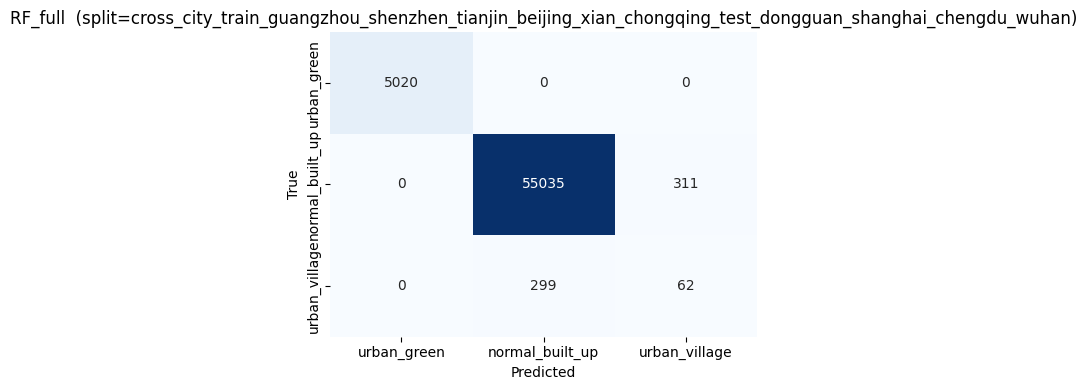

[[ 5020     0     0]
 [    0 55035   311]
 [    0   299    62]]

XGB_full
                 precision    recall  f1-score   support

    urban_green      1.000     1.000     1.000      5020
normal_built_up      0.995     0.993     0.994     55346
  urban_village      0.146     0.183     0.163       361

       accuracy                          0.989     60727
      macro avg      0.714     0.725     0.719     60727
   weighted avg      0.990     0.989     0.989     60727

Confusion matrix (rows=true, cols=pred):
                 urban_green  normal_built_up  urban_village
urban_green             5020                0              0
normal_built_up            0            54961            385
urban_village              0              295             66


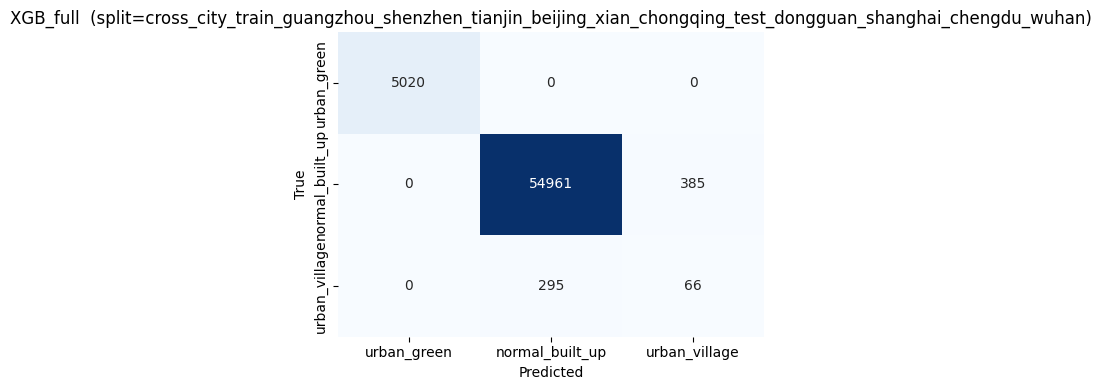

[[ 5020     0     0]
 [    0 54961   385]
 [    0   295    66]]


In [13]:
# ----------------------------------------------------------------------------
# 10. Train and evaluate models
# ----------------------------------------------------------------------------

def evaluate_multi_class_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)            # shape (n_test, n_classes)
    pred = model.classes_[np.argmax(proba, axis=1)]

    metrics = {
        "model": name,
        "macro_f1": f1_score(y_test, pred, average="macro", labels=CLASS_ORDER),
        "weighted_f1": f1_score(y_test, pred, average="weighted", labels=CLASS_ORDER),
        "balanced_acc": balanced_accuracy_score(y_test, pred),
        "macro_precision": precision_score(y_test, pred, average="macro", labels=CLASS_ORDER, zero_division=0),
        "macro_recall": recall_score(y_test, pred, average="macro", labels=CLASS_ORDER, zero_division=0),
    }
    # Per-class F1
    per_class_f1 = f1_score(y_test, pred, average=None, labels=CLASS_ORDER, zero_division=0)
    for cls, f1_val in zip(CLASS_ORDER, per_class_f1):
        metrics[f"f1_{CLASS_NAMES[cls]}"] = f1_val
    return model, proba, pred, metrics


def plot_confusion_matrix(cm_df, title, out_path):
    """Save a compact, report-ready confusion matrix.

    The labels are shortened so they fit inside the figure when displayed in
    GitHub and in the final report. Full class names are preserved in the
    printed classification report above.
    """
    short_labels = ["Green", "Normal", "Village"]
    plot_df = cm_df.copy()
    plot_df.index = short_labels
    plot_df.columns = short_labels

    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    sns.heatmap(
        plot_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        square=True,
        annot_kws={"fontsize": 10},
        ax=ax,
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("Predicted label", fontsize=10)
    ax.set_ylabel("True label", fontsize=10)
    ax.tick_params(axis="x", labelrotation=0, labelsize=9)
    ax.tick_params(axis="y", labelrotation=0, labelsize=9)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


results = []
predictions = {}

tracker = None
if CODECARBON_AVAILABLE:
    tracker = EmissionsTracker(
        project_name="0069_urban_village_rf_xgboost",
        output_dir=str(OUTPUT_DIR),
        output_file="book2_codecarbon_emissions.csv",
        log_level="error",
    )
    tracker.start()

for name, model in models.items():
    fitted, proba, pred, metrics = evaluate_multi_class_model(name, model, X_train, y_train, X_test, y_test)
    models[name] = fitted
    predictions[name] = {"proba": proba, "pred": pred}
    results.append(metrics)

if tracker is not None:
    emissions = tracker.stop()
    print("Estimated emissions kgCO2e:", emissions)

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
display(results_df)
results_df.to_csv(OUTPUT_DIR / f"book2_model_metrics_{split_name}.csv", index=False)

# Per-model classification report and compact 3x3 confusion matrix.
# The saved figure style matches the report figures in /figures.
DISPLAY_TITLES = {
    "RF_full": "Random Forest",
    "XGB_full": "XGBoost",
}

for name in models:
    print("
", "=" * 80)
    print(name)
    print(classification_report(
        y_test, predictions[name]["pred"],
        labels=CLASS_ORDER,
        target_names=CLASS_LABELS_ORDERED,
        digits=3, zero_division=0,
    ))
    cm = confusion_matrix(y_test, predictions[name]["pred"], labels=CLASS_ORDER)
    cm_df = pd.DataFrame(cm, index=CLASS_LABELS_ORDERED, columns=CLASS_LABELS_ORDERED)
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm_df)

    plot_confusion_matrix(
        cm_df,
        title=DISPLAY_TITLES.get(name, name),
        out_path=OUTPUT_DIR / f"book2_confusion_{name}_{split_name}.png",
    )


### Step 11: Run feature ablation

**Purpose**: Measure how much each feature group contributes to classification performance.  
**Input**: predefined feature subsets and the same train/test split.  
**Output**: ablation metrics and a figure showing performance changes as S2, seasonal, texture, SAR, context, and road features are added.


[ok] X has no leaky OSM columns (sanity check passed)


,feature_set,n_features,macro_f1,weighted_f1,balanced_acc,f1_urban_green,f1_normal_built_up,f1_urban_village
5,S1_S2_context_roads,73,0.720043,0.989267,0.728833,1.000000,0.993660,0.166468
4,S1_S2_context,72,0.716863,0.989062,0.725972,1.000000,0.993497,0.157093
3,S1_S2_full,64,0.642930,0.952849,0.644324,0.774056,0.974102,0.180631
2,S2_full_texture,44,0.632446,0.944773,0.697012,0.763360,0.966296,0.167681
1,S2_annual_quarterly,38,0.628453,0.943681,0.693030,0.759194,0.965522,0.160643
0,S2_annual,18,0.608771,0.932104,0.697057,0.707335,0.957518,0.161461


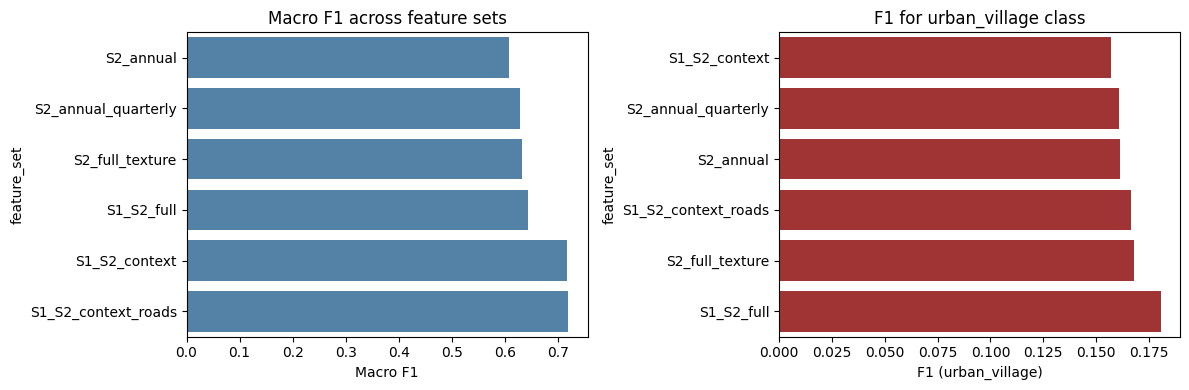

In [14]:
# ----------------------------------------------------------------------------
# 11. Feature ablation
# ----------------------------------------------------------------------------
# This answers the coursework-quality question:
# do multi-source EO and urban-context features improve over simple baselines?

def cols_containing(tokens):
    return [c for c in feature_cols if any(t in c.lower() for t in tokens)]

# Updated token groups to include all new Book 1 features (quarterly, GLCM, SWIR).
s2_annual_cols = cols_containing(
    ["s2_b2", "s2_b3", "s2_b4", "s2_b8", "s2_b11", "s2_b12",
     "s2_ndvi_mean", "s2_ndvi_stdDev",
     "s2_ndbi_mean", "s2_ndbi_stdDev",
     "s2_ndwi", "s2_bsi"]
)
s2_quarterly_cols = cols_containing(["q1_", "q2_", "q3_", "q4_", "quarterly"])
s2_texture_cols = cols_containing(["glcm", "swir_gray", "ndbi_texture"])
s2_cols = sorted(set(s2_annual_cols + s2_quarterly_cols + s2_texture_cols))

s1_cols = cols_containing(["vv", "vh", "s1_asc", "s1_desc"])
context_cols = cols_containing(["builtup", "vegetation", "water", "urban_surrounding"])
road_cols_all = [
    c for c in labelled.select_dtypes(include=[np.number]).columns
    if "road" in c.lower()
]
road_cols = [c for c in road_cols_all if c in X.columns]

# Sanity check: confirm no leaky OSM cols are in X (these were dropped earlier).
leaky_in_X = [c for c in X.columns if c in LEAKY_OSM_COLS]
assert not leaky_in_X, (
    f"FATAL: leaky OSM columns still in X: {leaky_in_X}. "
    "This will produce artificial F1=1.0. Re-run Cell 7."
)
print(f"[ok] X has no leaky OSM columns (sanity check passed)")

# Ablation tells a layered story:
# 1. S2 annual only        -> can vanilla optical do it?
# 2. + S2 quarterly        -> does seasonality help?
# 3. + S2 texture (GLCM)   -> does within-grid structure help?
# 4. + S1 (SAR)            -> does SAR-based roughness add anything?
# 5. + WorldCover context  -> does urban-context dominate everything?
# OSM road density is retained because it is not part of the label rule. The
# ablation below tests whether this morphology feature adds value over EO-only
# features.
feature_sets = {
    "S2_annual":              s2_annual_cols,
    "S2_annual_quarterly":    sorted(set(s2_annual_cols + s2_quarterly_cols)),
    "S2_full_texture":        s2_cols,
    "S1_S2_full":             sorted(set(s2_cols + s1_cols)),
    "S1_S2_context":          sorted(set(s2_cols + s1_cols + context_cols)),
}
if road_cols:
    feature_sets["S1_S2_context_roads"] = sorted(set(s2_cols + s1_cols + context_cols + road_cols))

ablation_rows = []

for fs_name, cols in feature_sets.items():
    cols = [c for c in cols if c in X.columns]
    if len(cols) == 0:
        continue

    model = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        num_class=len(CLASS_ORDER),
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train[cols], y_train)
    proba = model.predict_proba(X_test[cols])
    pred = model.classes_[np.argmax(proba, axis=1)]

    per_class_f1 = f1_score(y_test, pred, average=None, labels=CLASS_ORDER, zero_division=0)
    row = {
        "feature_set": fs_name,
        "n_features": len(cols),
        "macro_f1": f1_score(y_test, pred, average="macro", labels=CLASS_ORDER, zero_division=0),
        "weighted_f1": f1_score(y_test, pred, average="weighted", labels=CLASS_ORDER, zero_division=0),
        "balanced_acc": balanced_accuracy_score(y_test, pred),
    }
    for cls, val in zip(CLASS_ORDER, per_class_f1):
        row[f"f1_{CLASS_NAMES[cls]}"] = val
    ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows).sort_values("macro_f1", ascending=False)
display(ablation_df)
ablation_df.to_csv(OUTPUT_DIR / f"book2_feature_ablation_{split_name}.csv", index=False)

# Plot: macro F1 + per-class F1 for the urban_village class (most important)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=ablation_df.sort_values("macro_f1"),
            x="macro_f1", y="feature_set", color="steelblue", ax=axes[0])
axes[0].set_title("Macro F1 across feature sets")
axes[0].set_xlabel("Macro F1")

sns.barplot(data=ablation_df.sort_values("f1_urban_village"),
            x="f1_urban_village", y="feature_set", color="firebrick", ax=axes[1])
axes[1].set_title("F1 for urban_village class")
axes[1].set_xlabel("F1 (urban_village)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"book2_feature_ablation_{split_name}.png", dpi=200)
plt.show()

### Step 12: Explain XGBoost with SHAP

**Purpose**: Interpret which EO and morphology variables drive each class, especially the urban-village class.  
**Input**: trained XGBoost model, feature matrix, and class labels.  
**Output**: per-class SHAP summary plots and an importance CSV for the report.


SHAP raw shape: (2000, 75, 3)
X_shap shape: (2000, 75)


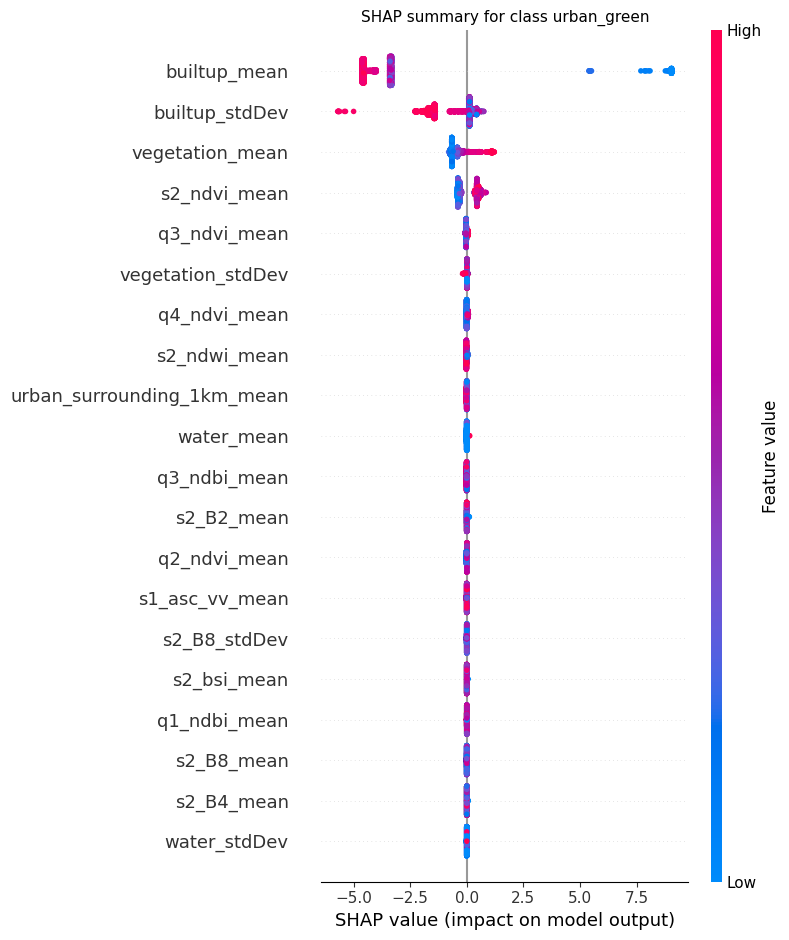

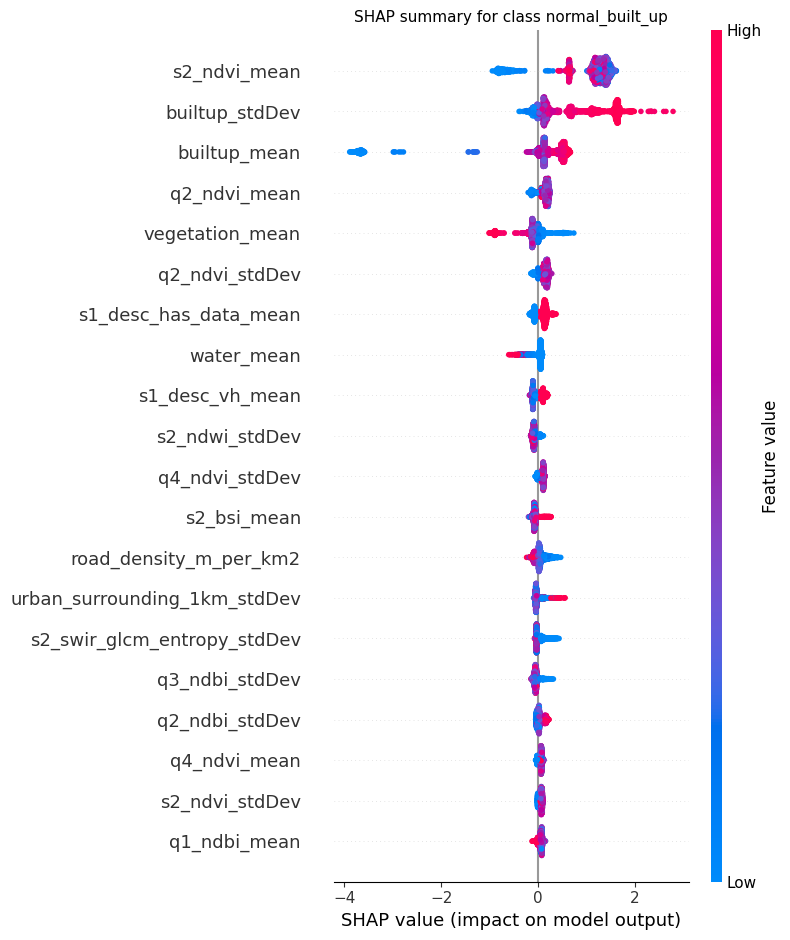

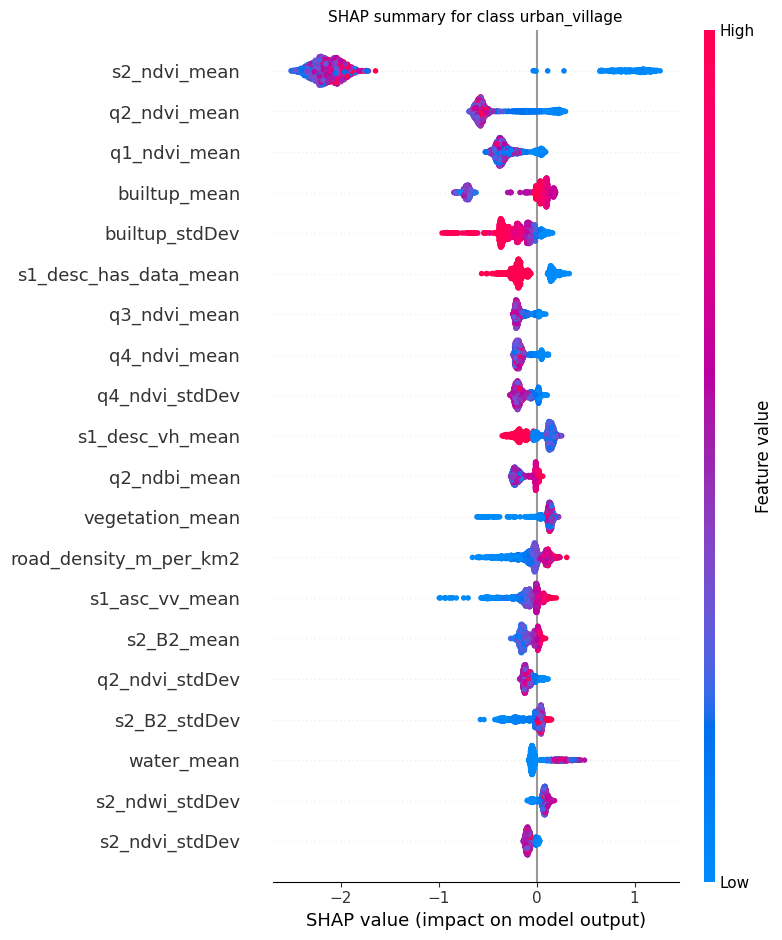

,feature,mean_abs_shap_overall,mean_abs_shap_urban_green,mean_abs_shap_normal_built_up,mean_abs_shap_urban_village
0,builtup_mean,1.747409,4.361086,0.588541,0.292599
60,s2_ndvi_mean,1.209667,0.419990,1.188715,2.020295
1,builtup_stdDev,0.587990,0.888296,0.671549,0.204124
70,vegetation_mean,0.273182,0.536568,0.150176,0.132803
12,q2_ndvi_mean,0.219220,0.002853,0.156792,0.498015
8,q1_ndvi_mean,0.118817,0.000000,0.037630,0.318821
32,s1_desc_has_data_mean,0.105939,0.000000,0.125251,0.192566
20,q4_ndvi_mean,0.081573,0.018246,0.058231,0.168241
34,s1_desc_vh_mean,0.078017,0.000000,0.095925,0.138127
13,q2_ndvi_stdDev,0.077438,0.000318,0.139584,0.092411


In [15]:
# ----------------------------------------------------------------------------
# 12. SHAP explanation for XGBoost (multi-class)
# ----------------------------------------------------------------------------
# SHAP for multi-class XGBoost returns one set of shap values per class.
# We plot a per-class summary, then a combined importance table.
# This matches the Week 9 XAI content and gives the report a clear
# "what makes a grid look like an urban village vs normal vs green" answer.

best_model = models["XGB_full"]

sample_n = min(2000, len(X_test))
X_shap = X_test.sample(sample_n, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    # older shap returns a list; newer returns a 3D array
    shap_values = np.array(shap_values)

print("SHAP raw shape:", getattr(shap_values, "shape", None))
print("X_shap shape:", X_shap.shape)

def shap_values_for_class(shap_values_array, class_idx, n_samples, n_features, n_classes):
    """Return a (n_samples, n_features) SHAP matrix for one class.

    SHAP has changed its multi-class return convention across versions:
    - older API: (n_classes, n_samples, n_features)
    - newer API: (n_samples, n_features, n_classes)
    This helper handles both and avoids summary_plot shape errors.
    """
    if shap_values_array.ndim == 2:
        return shap_values_array
    if shap_values_array.ndim != 3:
        raise ValueError(f"Unexpected SHAP array shape: {shap_values_array.shape}")

    if shap_values_array.shape == (n_classes, n_samples, n_features):
        return shap_values_array[class_idx, :, :]
    if shap_values_array.shape == (n_samples, n_features, n_classes):
        return shap_values_array[:, :, class_idx]

    # Defensive fallbacks for minor API variations.
    if shap_values_array.shape[0] == n_classes and shap_values_array.shape[2] == n_features:
        return shap_values_array[class_idx, :, :]
    if shap_values_array.shape[2] == n_classes and shap_values_array.shape[1] == n_features:
        return shap_values_array[:, :, class_idx]

    raise ValueError(
        f"Cannot align SHAP values {shap_values_array.shape} with X {X_shap.shape} "
        f"and {n_classes} classes."
    )

# Per-class SHAP summary plots
n_samples, n_features = X_shap.shape
n_classes = len(CLASS_ORDER)
class_shap_mats = []
for class_idx, cls in enumerate(CLASS_ORDER):
    sv = shap_values_for_class(shap_values, class_idx, n_samples, n_features, n_classes)
    class_shap_mats.append(sv)
    plt.figure()
    shap.summary_plot(sv, X_shap, show=False, max_display=20)
    plt.title(f"SHAP summary for class {CLASS_NAMES[cls]}", fontsize=11)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"book2_shap_summary_class_{CLASS_NAMES[cls]}_{split_name}.png",
        dpi=220, bbox_inches="tight"
    )
    plt.show()

# Combined importance: mean |shap| across classes and samples
if len(class_shap_mats) == n_classes:
    importance_per_class = np.vstack([
        np.abs(sv).mean(axis=0) for sv in class_shap_mats
    ])
    importance_overall = importance_per_class.mean(axis=0)
    importance_df = pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap_overall": importance_overall,
    })
    for class_idx, cls in enumerate(CLASS_ORDER):
        importance_df[f"mean_abs_shap_{CLASS_NAMES[cls]}"] = importance_per_class[class_idx]
else:
    importance_df = pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap_overall": np.abs(shap_values).mean(axis=0),
    })

importance_df = importance_df.sort_values("mean_abs_shap_overall", ascending=False)
display(importance_df.head(25))
importance_df.to_csv(OUTPUT_DIR / f"book2_shap_importance_{split_name}.csv", index=False)

### Step 13: Export prediction maps and validation samples

**Purpose**: Save RF and XGBoost predictions as GeoJSON layers and create a compact sample for manual inspection.  
**Input**: model probabilities, predicted classes, and test-grid geometries.  
**Output**: full and per-city prediction maps plus high-confidence, uncertain, and disagreement samples.


In [16]:
# ----------------------------------------------------------------------------
# 13. Save prediction map for manual inspection (multi-class)
# ----------------------------------------------------------------------------
# For each test grid and each fitted model we save:
# - predicted class
# - per-class probability (3 columns)
# - village probability specifically (most operationally important)
# - max probability and an entropy-based uncertainty metric
#
# This means every main Book 2 model can be mapped directly in QGIS:
# RF gives the robust baseline map; XGBoost gives the main model map.
# Manual validation focuses on the urban_village class because the user
# already trusts the urban_green / normal_built_up boundary (NDVI / builtup
# do the heavy lifting there), while village vs normal is the hard call.

def prediction_map_for_model(model_name: str, prefix: str) -> gpd.GeoDataFrame:
    proba = predictions[model_name]["proba"]
    pred = predictions[model_name]["pred"]
    classes = models[model_name].classes_

    out = test_gdf.copy()
    out["true_weak_label"] = y_test.values
    out["true_weak_label_name"] = out["true_weak_label"].map(CLASS_NAMES)
    out[f"{prefix}_prediction"] = pred
    out[f"{prefix}_prediction_name"] = out[f"{prefix}_prediction"].map(CLASS_NAMES)

    for class_idx, cls in enumerate(classes):
        out[f"{prefix}_prob_{CLASS_NAMES[cls]}"] = proba[:, class_idx]

    out[f"{prefix}_village_probability"] = out[f"{prefix}_prob_{CLASS_NAMES[CLASS_VILLAGE]}"]
    out[f"{prefix}_max_probability"] = proba.max(axis=1)
    out[f"{prefix}_pred_entropy"] = -np.sum(
        proba * np.log(np.clip(proba, 1e-9, 1)), axis=1
    )
    return out


model_map_outputs = {}
for model_name, prefix in [("RF_full", "rf"), ("XGB_full", "xgb")]:
    model_map = prediction_map_for_model(model_name, prefix)
    model_map_outputs[prefix] = model_map
    out_path = OUTPUT_DIR / f"book2_v3_{prefix}_predictions_{split_name}.geojson"
    model_map.to_file(out_path, driver="GeoJSON")
    print(f"Saved {model_name} prediction map:", out_path)
    for city, city_map in model_map.groupby("city"):
        city_out_path = OUTPUT_DIR / f"book2_v3_{prefix}_predictions_{city}_{split_name}.geojson"
        city_map.to_file(city_out_path, driver="GeoJSON")
        print(f"  saved {city} map:", city_out_path.name)

# XGBoost remains the main model used to generate the manual validation sample.
test_gdf = model_map_outputs["xgb"].copy()
test_gdf["village_probability"] = test_gdf["xgb_village_probability"]
test_gdf["max_probability"] = test_gdf["xgb_max_probability"]
test_gdf["pred_entropy"] = test_gdf["xgb_pred_entropy"]

# Manual validation sample. We sample 5 categories x 50 grids = 250 total:
# - top-50 village-probability grids (where model is confident village)
# - top-50 normal-probability grids (where model is confident normal)
# - top-50 green-probability grids (where model is confident green)
# - top-50 highest entropy grids (where model is most confused)
# - top-50 disagreements vs weak label that involve the village class
high_village = test_gdf.sort_values("village_probability", ascending=False).head(50)
high_normal = test_gdf.sort_values(f"xgb_prob_{CLASS_NAMES[CLASS_NORMAL]}", ascending=False).head(50)
high_green = test_gdf.sort_values(f"xgb_prob_{CLASS_NAMES[CLASS_GREEN]}", ascending=False).head(50)
uncertain = test_gdf.sort_values("pred_entropy", ascending=False).head(50)

village_disagree = test_gdf[
    ((test_gdf["xgb_prediction"] == CLASS_VILLAGE) & (test_gdf["true_weak_label"] != CLASS_VILLAGE))
    | ((test_gdf["xgb_prediction"] != CLASS_VILLAGE) & (test_gdf["true_weak_label"] == CLASS_VILLAGE))
].sort_values("village_probability", ascending=False).head(50)

validation_sample = pd.concat(
    [
        high_village.assign(sample_reason="confident_village"),
        high_normal.assign(sample_reason="confident_normal"),
        high_green.assign(sample_reason="confident_green"),
        uncertain.assign(sample_reason="highest_entropy"),
        village_disagree.assign(sample_reason="village_disagreement"),
    ],
    ignore_index=True,
).drop_duplicates(subset=["grid_id", "city"])

validation_sample.to_file(
    OUTPUT_DIR / f"book2_v3_manual_validation_sample_{split_name}.geojson", driver="GeoJSON"
)
validation_sample.drop(columns="geometry").to_csv(
    OUTPUT_DIR / f"book2_v3_manual_validation_sample_{split_name}.csv",
    index=False,
)

print("Saved prediction and validation files to:", OUTPUT_DIR)

Saved RF_full prediction map: /content/drive/MyDrive/0069/week10/outputs/book2_v3_rf_predictions_cross_city_train_guangzhou_shenzhen_tianjin_beijing_xian_chongqing_test_dongguan_shanghai_chengdu_wuhan.geojson
  saved chengdu map: book2_v3_rf_predictions_chengdu_cross_city_train_guangzhou_shenzhen_tianjin_beijing_xian_chongqing_test_dongguan_shanghai_chengdu_wuhan.geojson
  saved dongguan map: book2_v3_rf_predictions_dongguan_cross_city_train_guangzhou_shenzhen_tianjin_beijing_xian_chongqing_test_dongguan_shanghai_chengdu_wuhan.geojson
  saved shanghai map: book2_v3_rf_predictions_shanghai_cross_city_train_guangzhou_shenzhen_tianjin_beijing_xian_chongqing_test_dongguan_shanghai_chengdu_wuhan.geojson
  saved wuhan map: book2_v3_rf_predictions_wuhan_cross_city_train_guangzhou_shenzhen_tianjin_beijing_xian_chongqing_test_dongguan_shanghai_chengdu_wuhan.geojson
Saved XGB_full prediction map: /content/drive/MyDrive/0069/week10/outputs/book2_v3_xgb_predictions_cross_city_train_guangzhou_shenz

### Step 14: Save the processed table for GraphSAGE

**Purpose**: Package the same labelled grids and feature list for the graph model in Book 3.  
**Input**: `labelled`, `feature_cols`, and grid geometries.  
**Output**: `book3_gnn_input.csv`, `book3_gnn_input.geojson`, and `book3_feature_cols.json`.


In [17]:
# ----------------------------------------------------------------------------
# 14. Save a lightweight CSV for Book 3 GNN
# ----------------------------------------------------------------------------
# Book 3 reads this table and builds a graph from grid centroids.

gnn_input = labelled.copy()
gnn_input["centroid_lon"] = gnn_input.geometry.centroid.x
gnn_input["centroid_lat"] = gnn_input.geometry.centroid.y

gnn_input.drop(columns="geometry").to_csv(PROCESSED_DIR / "book3_gnn_input.csv", index=False)
gnn_input.to_file(PROCESSED_DIR / "book3_gnn_input.geojson", driver="GeoJSON")

with open(PROCESSED_DIR / "book3_feature_cols.json", "w") as f:
    json.dump(feature_cols, f, indent=2)

print("Saved Book 3 input:", PROCESSED_DIR / "book3_gnn_input.csv")
print("Saved Book 3 geometry input:", PROCESSED_DIR / "book3_gnn_input.geojson")

Saved Book 3 input: /content/drive/MyDrive/0069/week10/processed/book3_gnn_input.csv
Saved Book 3 geometry input: /content/drive/MyDrive/0069/week10/processed/book3_gnn_input.geojson
